## Exercício de SVM 

**Fraude em Vinhos**
- A fraude em vinhos está relacionada aos aspectos comerciais do produto. O tipo mais comum de fraude envolve a adulteração de vinhos, geralmente pela adição de produtos mais baratos (como sucos) e, por vezes, de substâncias químicas nocivas e adoçantes (para corrigir a cor ou o sabor).
- O dataset possui dados de uma distribuidora de vinhos caros e de altíssima qualidade.
- Criar um modelo de aprendizado de máquina capaz de identificar amostras de vinho de baixa qualidade (ou seja, casos de "fraude"). O objetivo é verificar se é possível detectar essa diferença.

Data Source: *P. Cortez, A. Cerdeira, F. Almeida, T. Matos e J. Reis. Modeling wine preferences by data mining from physicochemical properties.
In Decision Support Systems, Elsevier, 47(4):547-553, 2009.*


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, SVR, LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("./data/wine_fraud.csv")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [4]:
df['quality'].unique()

array(['Legit', 'Fraud'], dtype=object)

<Axes: xlabel='quality', ylabel='count'>

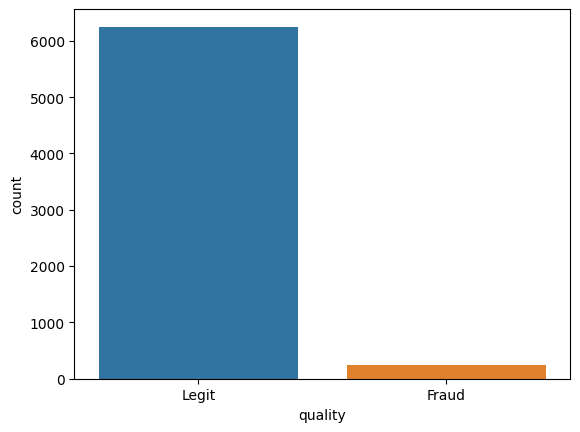

In [12]:
sns.countplot(x='quality', data=df, hue='quality', palette='tab10')

<Axes: xlabel='type', ylabel='count'>

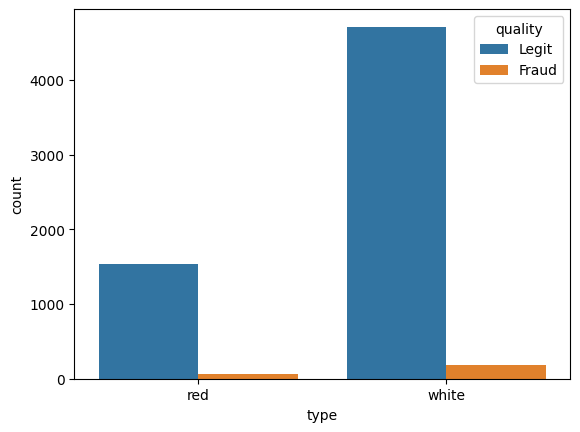

In [13]:
sns.countplot(x='type', data=df, hue='quality', palette='tab10')

In [28]:
fraud_percentage = (
    df.groupby('type')['quality']
      .apply(lambda x: (x == 'Fraud').mean() * 100)
)

In [29]:
print(f"Porcentagen de vinhos brancos fraudulentos: {fraud_percentage['white']:.2f}%")

Porcentagen de vinhos brancos fraudulentos: 3.74%


In [30]:
print(f"Porcentagem de vinhos tintos fraudulentos: {fraud_percentage['red']:.2f}%")

Porcentagem de vinhos tintos fraudulentos: 3.94%


In [38]:
df['Fraud'] = df['quality'].apply(lambda x: 1 if x == 'Fraud' else 0)

In [40]:
corr_fraud = df.select_dtypes(include=[np.number]).corrwith(df['Fraud'])
print(corr_fraud)

fixed acidity           0.021794
volatile acidity        0.151228
citric acid            -0.061789
residual sugar         -0.048756
chlorides               0.034499
free sulfur dioxide    -0.085204
total sulfur dioxide   -0.035252
density                 0.016351
pH                      0.020107
sulphates              -0.034046
alcohol                -0.051141
Fraud                   1.000000
dtype: float64


(-1.0, 12.0)

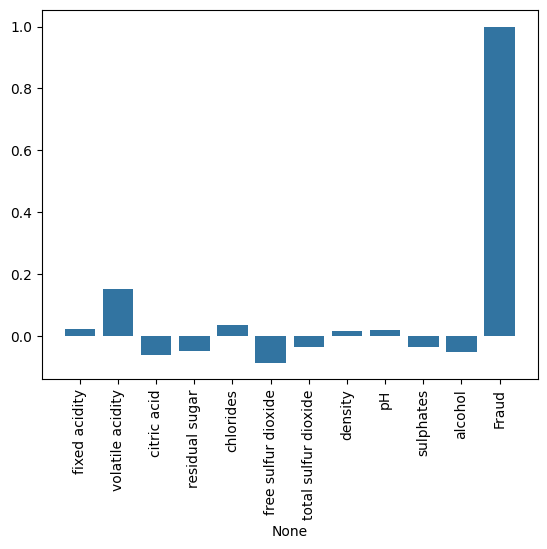

In [43]:
sns.barplot(x=corr_fraud.index, y=corr_fraud.values)
plt.xticks(rotation=90)
plt.xlim(-1, len(corr_fraud))